# Home task: Time Series Forecast 

## 1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## 2 Data Loading 

In [2]:
df = pd.read_csv("data/electricity_consumption_and_production.csv")

df["DateTime"] = pd.to_datetime(df["DateTime"])

df = df.set_index("DateTime").sort_index()

df.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


### Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 54161 entries, 2019-01-01 00:00:00 to 2025-03-19 23:00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Consumption    54161 non-null  int64
 1   Production     54161 non-null  int64
 2   Nuclear        54161 non-null  int64
 3   Wind           54161 non-null  int64
 4   Hydroelectric  54161 non-null  int64
 5   Oil and Gas    54161 non-null  int64
 6   Coal           54161 non-null  int64
 7   Solar          54161 non-null  int64
 8   Biomass        54161 non-null  int64
dtypes: int64(9)
memory usage: 4.1 MB


### Daily Resampling

In [4]:
consumption = df["Consumption"]

daily_consumption = consumption.resample("D").mean()

print("Original shape:", df.shape)
print("Daily series shape:", daily_consumption.shape)
print("Missing values:", daily_consumption.isna().sum())

daily_consumption.head()

Original shape: (54161, 9)
Daily series shape: (2270,)
Missing values: 2


DateTime
2019-01-01    5924.478261
2019-01-02    6322.041667
2019-01-03    7254.083333
2019-01-04    7635.083333
2019-01-05    7423.521739
Freq: D, Name: Consumption, dtype: float64

### Daily Consumption Plot

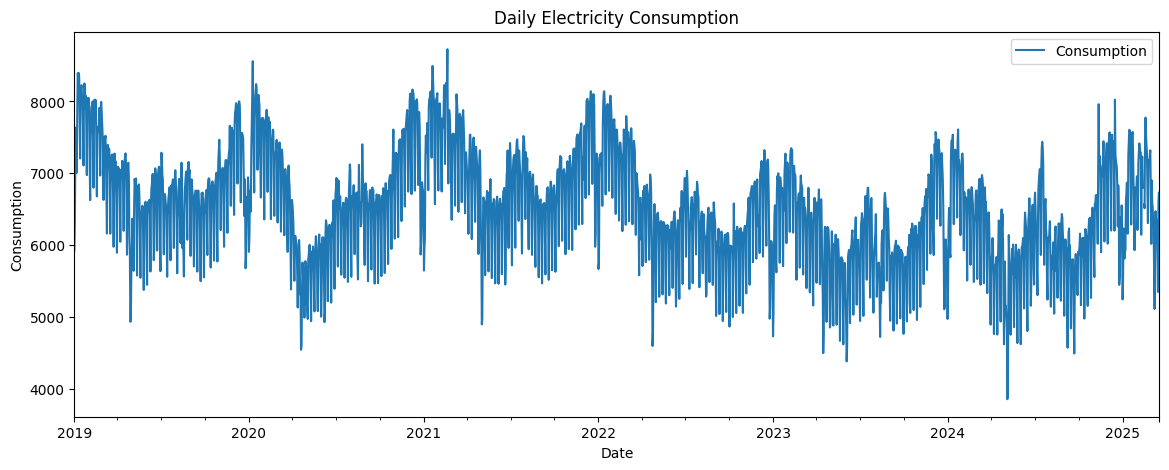

In [5]:
plt.figure(figsize=(14, 5))

daily_consumption.plot()

plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.legend(["Consumption"])
plt.show()

## 3 Exploratory Data Analysis


### Import Time Series Analysis Tools

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

### Time Series Decomposition

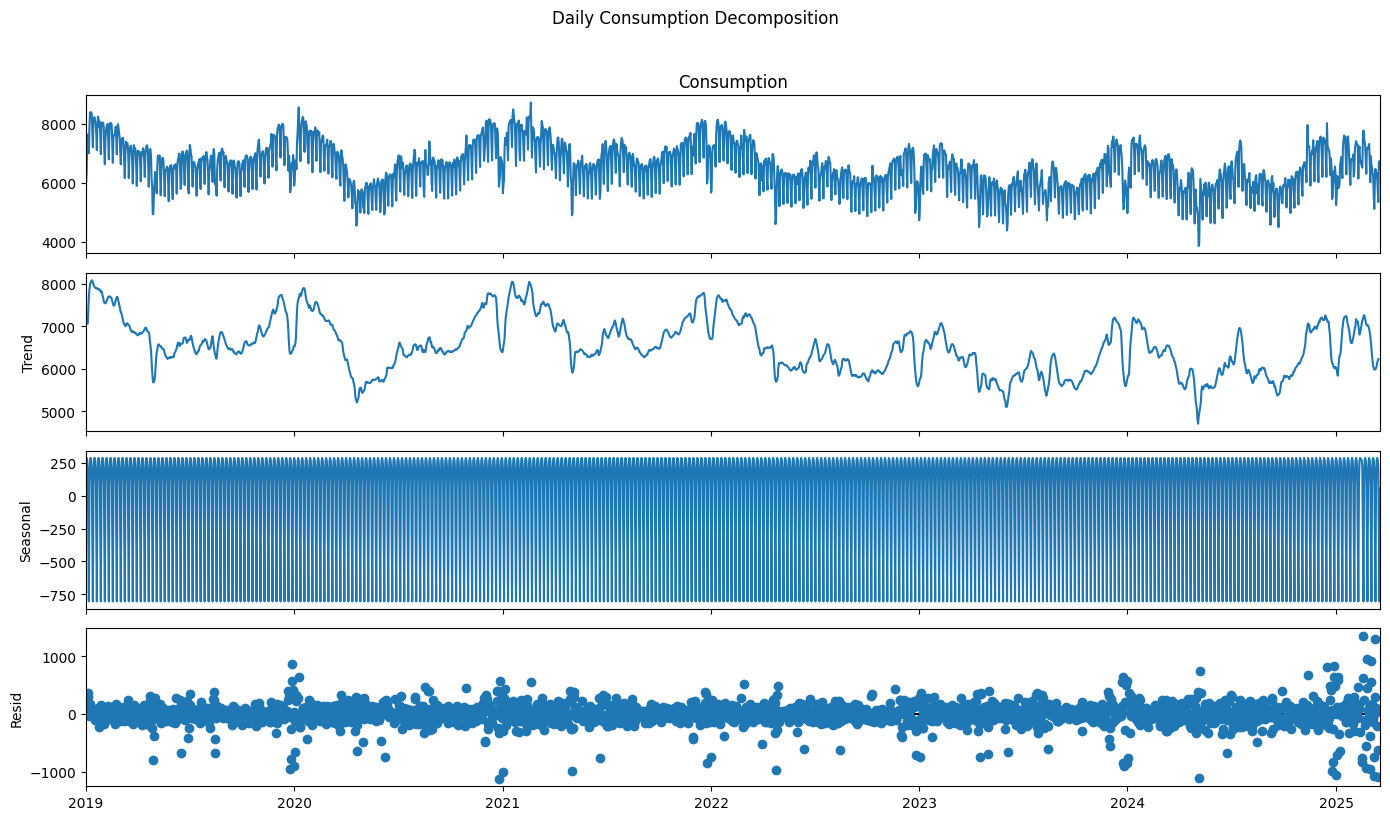

In [7]:
decomposition = seasonal_decompose(
    daily_consumption.dropna(),
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(14, 8)

plt.suptitle("Daily Consumption Decomposition", y=1.02)
plt.tight_layout()
plt.show()

### ACF and PACF

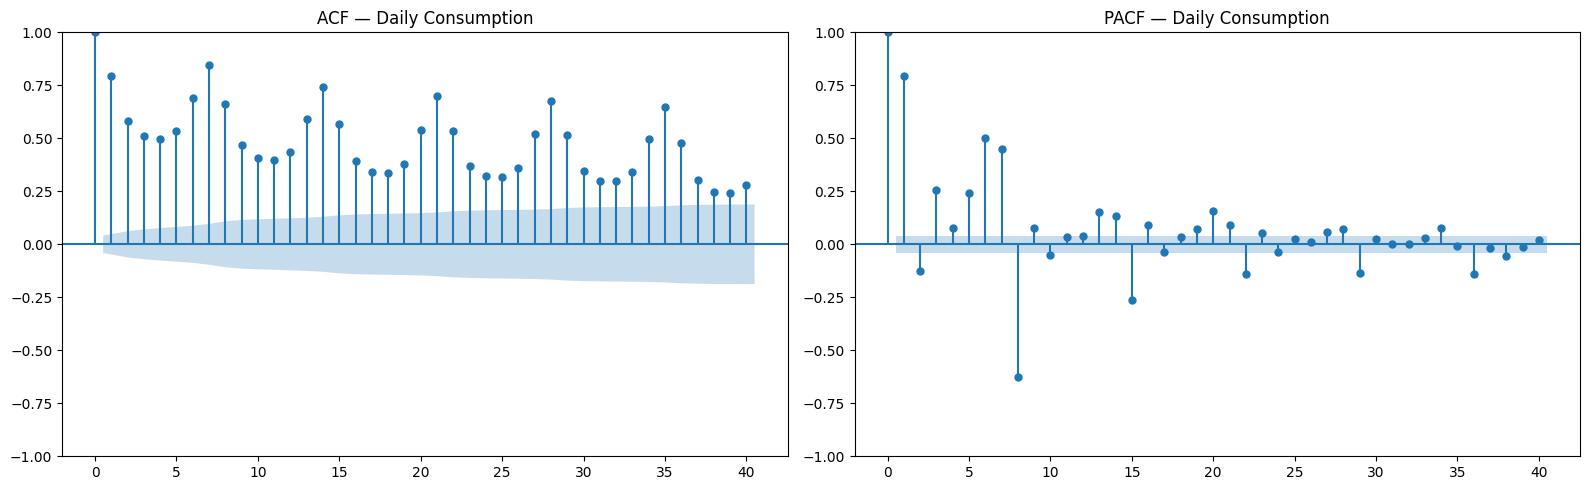

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(daily_consumption.dropna(), lags=40, ax=ax[0])
plot_pacf(daily_consumption.dropna(), lags=40, ax=ax[1])

ax[0].set_title("ACF — Daily Consumption")
ax[1].set_title("PACF — Daily Consumption")

plt.tight_layout()
plt.show()

### ADF Test Results

In [9]:
adf_result = adfuller(daily_consumption.dropna())

adf_table = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "p-value",
        "Used Lags",
        "Number of Observations"
    ],
    "Value": [
        adf_result[0],
        adf_result[1],
        adf_result[2],
        adf_result[3]
    ]
})

adf_table

,Metric,Value
0,ADF Statistic,-3.433197
1,p-value,0.009878
2,Used Lags,27.000000
3,Number of Observations,2240.000000


### ADF Test Interpretation

In [10]:
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

if adf_result[1] <= 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")

Critical Value (1%): -3.4333
Critical Value (5%): -2.8628
Critical Value (10%): -2.5675
The series is stationary


## 4 Preprocessing 


### Prepare Daily DataFrame

In [11]:
daily_df = daily_consumption.reset_index()

daily_df.columns = ["DateTime", "Consumption"]

daily_df["Consumption"] = daily_df["Consumption"].interpolate()

daily_df = daily_df.dropna()

daily_df.head()

,DateTime,Consumption
0,2019-01-01,5924.478261
1,2019-01-02,6322.041667
2,2019-01-03,7254.083333
3,2019-01-04,7635.083333
4,2019-01-05,7423.521739


### Dataset Information

In [12]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2270 entries, 0 to 2269
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DateTime     2270 non-null   datetime64[ns]
 1   Consumption  2270 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 35.6 KB


### Import Darts Tools

In [13]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

### Create TimeSeries Object

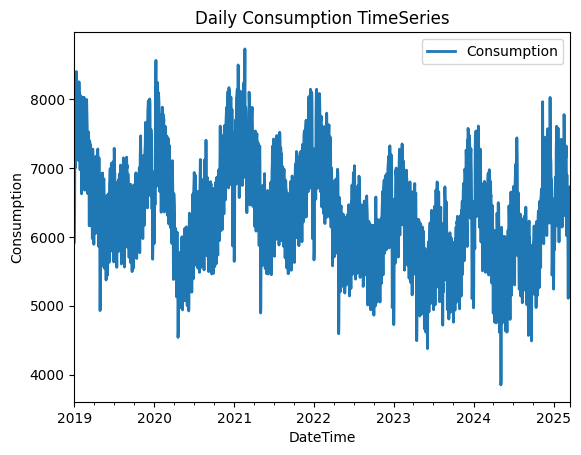

In [14]:
series = TimeSeries.from_dataframe(
    daily_df,
    time_col="DateTime",
    value_cols="Consumption",
    freq="D"
)

series.plot(label="Consumption")

plt.title("Daily Consumption TimeSeries")
plt.ylabel("Consumption")
plt.legend()
plt.show()

### Train-Test Split

In [15]:
train_15, test_15 = series[:-15], series[-15:]
train_30, test_30 = series[:-30], series[-30:]
train_45, test_45 = series[:-45], series[-45:]

print("15 days:", len(train_15), len(test_15))
print("30 days:", len(train_30), len(test_30))
print("45 days:", len(train_45), len(test_45))

15 days: 2255 15
30 days: 2240 30
45 days: 2225 45


### Scale Time Series Data

In [16]:
scaler = Scaler()

train_15_scaled = scaler.fit_transform(train_15)
test_15_scaled = scaler.transform(test_15)

train_30_scaled = scaler.fit_transform(train_30)
test_30_scaled = scaler.transform(test_30)

train_45_scaled = scaler.fit_transform(train_45)
test_45_scaled = scaler.transform(test_45)

series_scaled = scaler.fit_transform(series)

### Forecasting Models

### Import Forecasting Metrics

In [17]:
from darts.metrics import mape

### Forecast Evaluation Function

In [18]:
def evaluate_forecast(actual, forecast):
    return round(mape(actual, forecast), 3)

### Store Model Results

In [19]:
results = []
forecasts = {}

## 5.1 Exponential Smoothing

### Import Exponential Smoothing Model

In [20]:
from darts.models import ExponentialSmoothing

### Train Exponential Smoothing Models

In [21]:
ets_splits = {
    15: (train_15, test_15),
    30: (train_30, test_30),
    45: (train_45, test_45)
}

for horizon, (train, test) in ets_splits.items():
    model = ExponentialSmoothing(seasonal_periods=7)
    model.fit(train)
    forecast = model.predict(horizon)

    forecasts[f"ETS_{horizon}"] = forecast

    results.append({
        "Model": "Exponential Smoothing",
        "Horizon": horizon,
        "MAPE": evaluate_forecast(test, forecast)
    })

### Exponential Smoothing Forecast Visualization

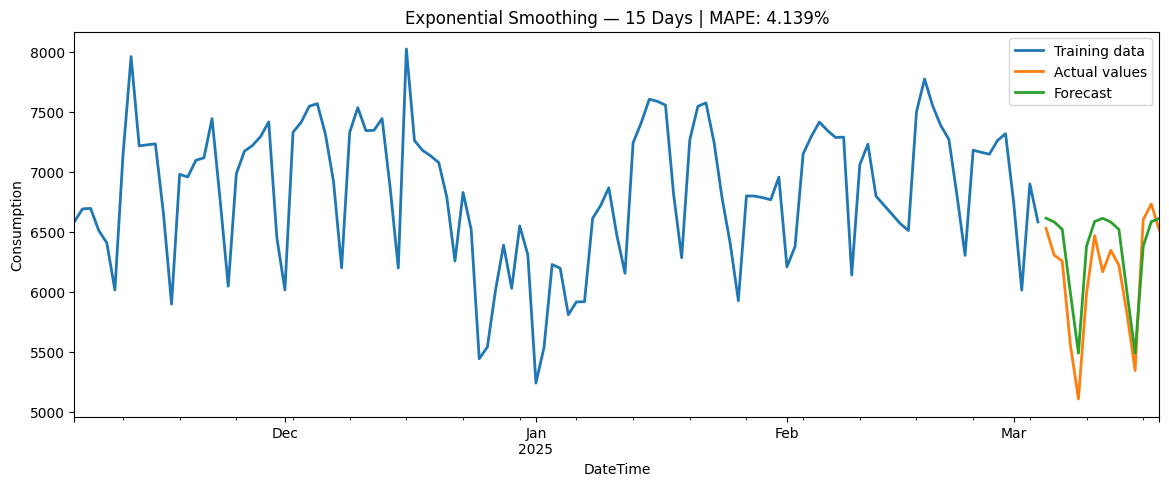

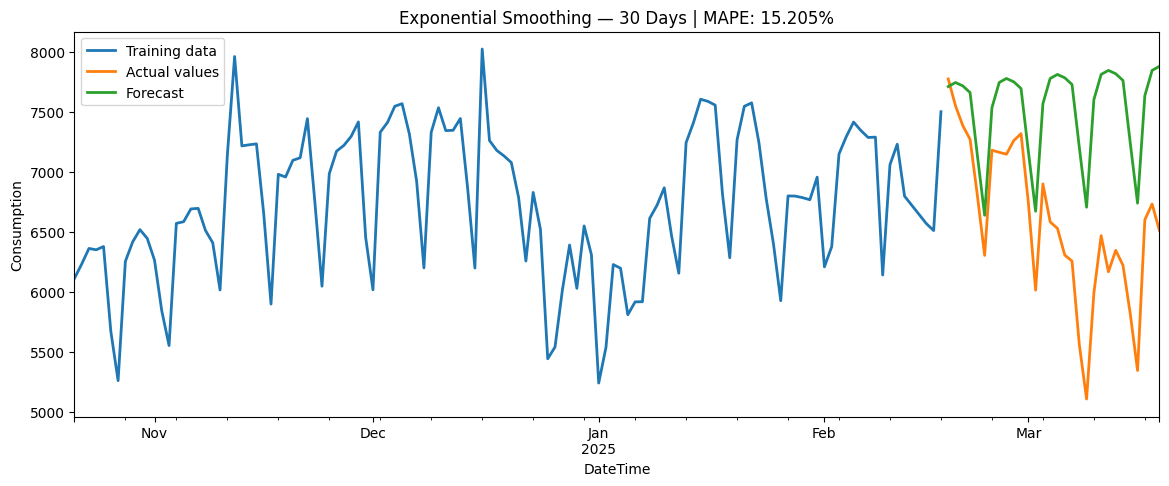

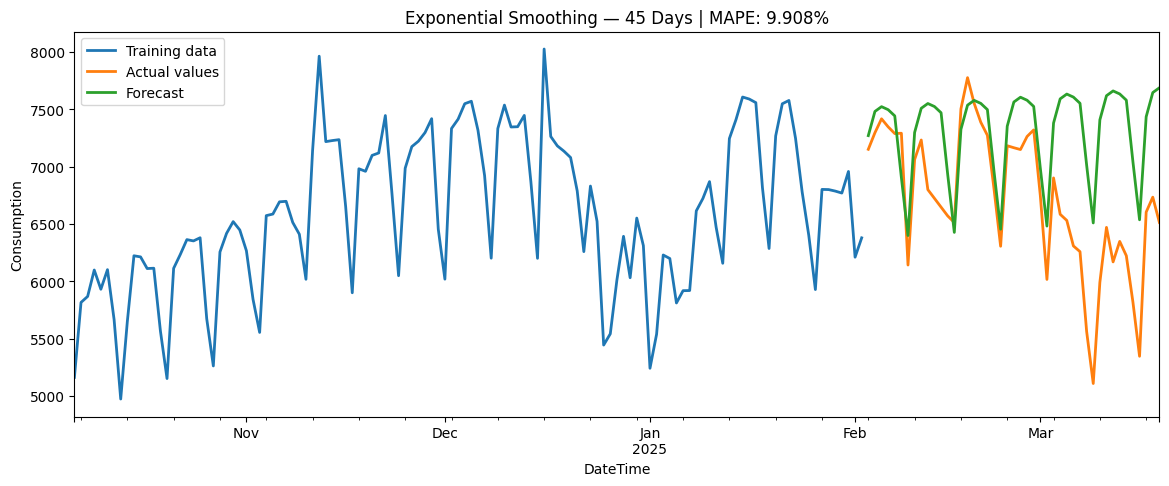

In [22]:
for horizon, (train, test) in ets_splits.items():
    forecast = forecasts[f"ETS_{horizon}"]
    score = evaluate_forecast(test, forecast)

    plt.figure(figsize=(14, 5))

    train[-120:].plot(label="Training data")
    test.plot(label="Actual values")
    forecast.plot(label="Forecast")

    plt.title(f"Exponential Smoothing — {horizon} Days | MAPE: {score}%")
    plt.ylabel("Consumption")
    plt.legend()
    plt.show()

## 5.2 SARIMA

### Import SARIMA Model

In [23]:
from darts.models import ARIMA

### Train SARIMA Models

In [24]:
sarima_splits = {
    15: (train_15, test_15),
    30: (train_30, test_30),
    45: (train_45, test_45)
}

for horizon, (train, test) in sarima_splits.items():
    model = ARIMA(
        p=2,
        d=1,
        q=2,
        seasonal_order=(1, 1, 1, 7)
    )

    model.fit(train)
    forecast = model.predict(horizon)

    forecasts[f"SARIMA_{horizon}"] = forecast

    results.append({
        "Model": "SARIMA",
        "Horizon": horizon,
        "MAPE": evaluate_forecast(test, forecast)
    })

### SARIMA Forecast Visualization

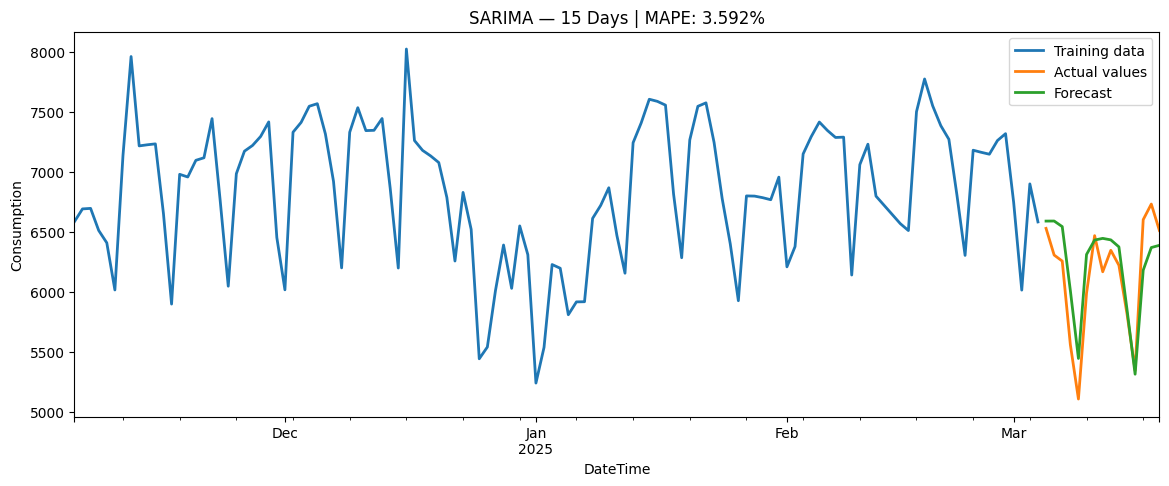

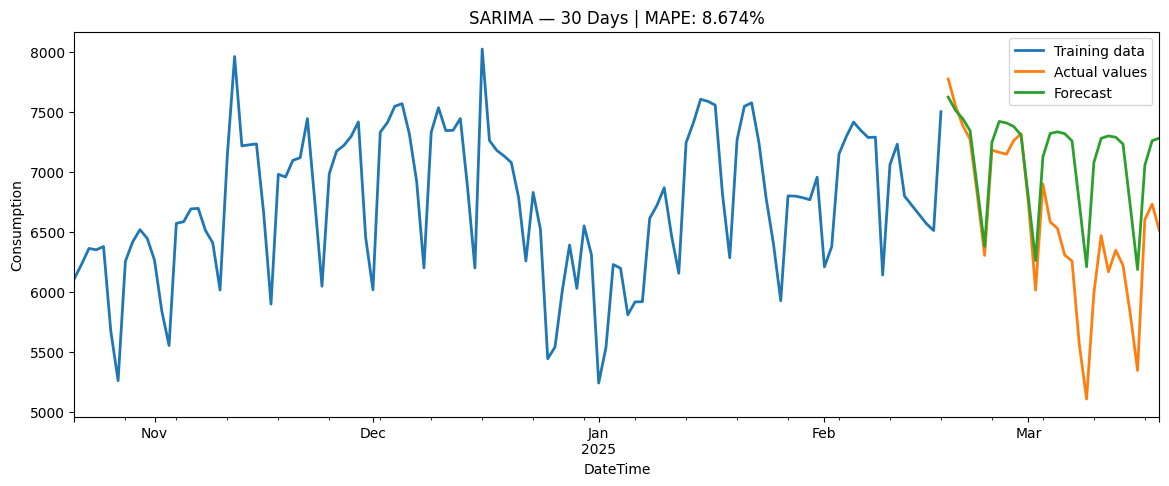

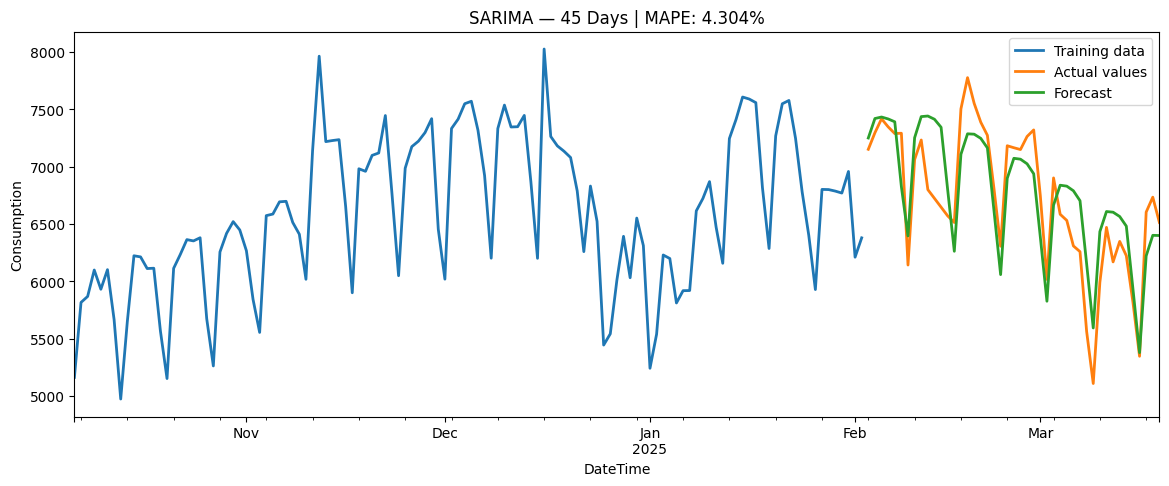

In [25]:
for horizon, (train, test) in sarima_splits.items():
    forecast = forecasts[f"SARIMA_{horizon}"]
    score = evaluate_forecast(test, forecast)

    plt.figure(figsize=(14, 5))

    train[-120:].plot(label="Training data")
    test.plot(label="Actual values")
    forecast.plot(label="Forecast")

    plt.title(f"SARIMA — {horizon} Days | MAPE: {score}%")
    plt.ylabel("Consumption")
    plt.legend()
    plt.show()

### Current Results

In [26]:
results_df = pd.DataFrame(results)

results_df

,Model,Horizon,MAPE
0,Exponential Smoothing,15,4.139
1,Exponential Smoothing,30,15.205
2,Exponential Smoothing,45,9.908
3,SARIMA,15,3.592
4,SARIMA,30,8.674
5,SARIMA,45,4.304


### MAPE Results Table

In [27]:
results_pivot = results_df.pivot_table(
    index="Model",
    columns="Horizon",
    values="MAPE"
)

results_pivot

Horizon,15,30,45
Model,,,
Exponential Smoothing,4.139,15.205,9.908
SARIMA,3.592,8.674,4.304


## 5.3 Prophet

### Import Prophet Model

In [28]:
from darts.models import Prophet

Importing plotly failed. Interactive plots will not work.


### Train Prophet Models

In [29]:
prophet_splits = {
    15: (train_15, test_15),
    30: (train_30, test_30),
    45: (train_45, test_45)
}

for horizon, (train, test) in prophet_splits.items():
    model = Prophet()

    model.fit(train)
    forecast = model.predict(horizon)

    forecasts[f"Prophet_{horizon}"] = forecast

    results.append({
        "Model": "Prophet",
        "Horizon": horizon,
        "MAPE": evaluate_forecast(test, forecast)
    })

02:13:13 - cmdstanpy - INFO - Chain [1] start processing
02:13:13 - cmdstanpy - INFO - Chain [1] done processing
02:13:14 - cmdstanpy - INFO - Chain [1] start processing
02:13:14 - cmdstanpy - INFO - Chain [1] done processing
02:13:14 - cmdstanpy - INFO - Chain [1] start processing
02:13:15 - cmdstanpy - INFO - Chain [1] done processing


### Prophet Forecast Visualization

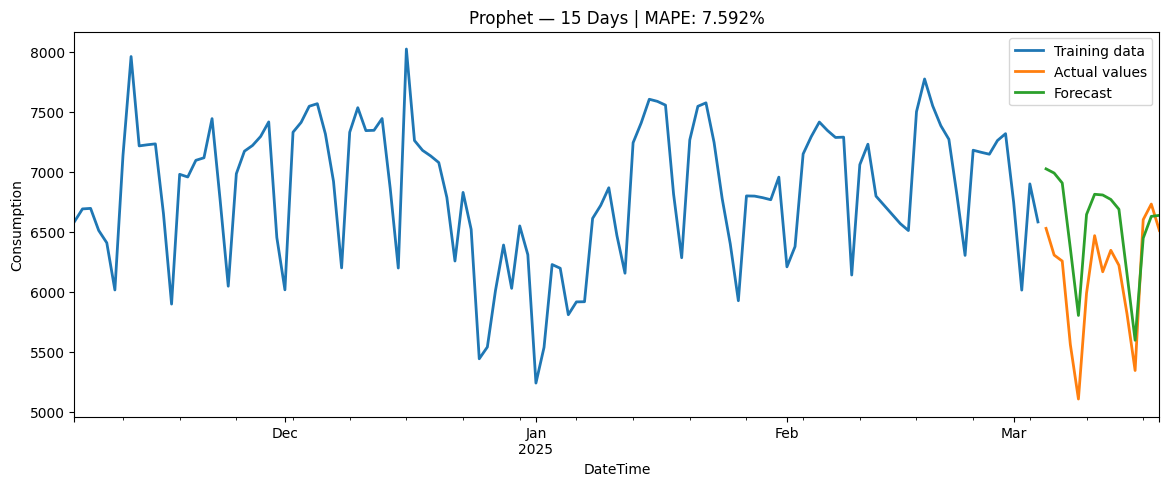

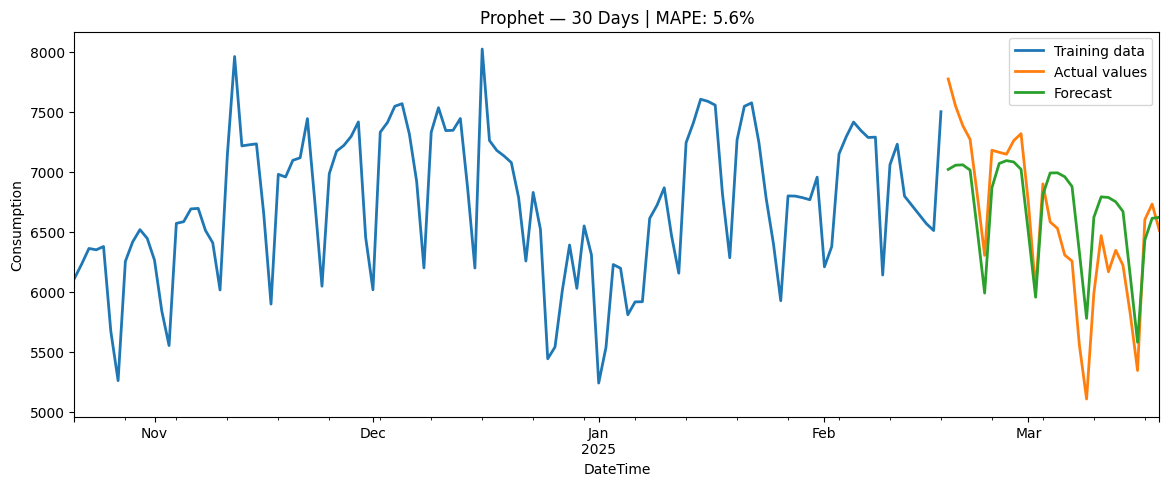

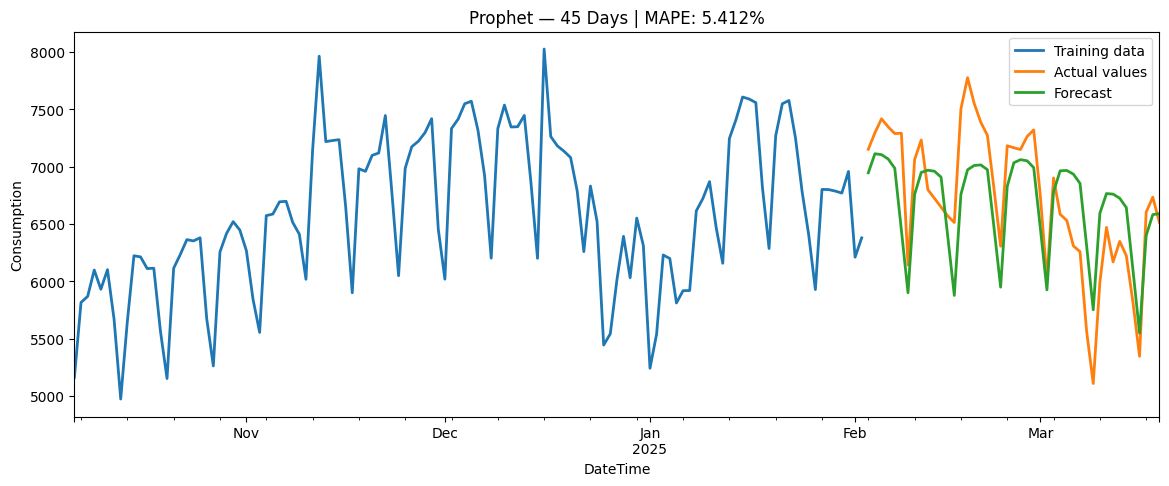

In [30]:
for horizon, (train, test) in prophet_splits.items():
    forecast = forecasts[f"Prophet_{horizon}"]
    score = evaluate_forecast(test, forecast)

    plt.figure(figsize=(14, 5))

    train[-120:].plot(label="Training data")
    test.plot(label="Actual values")
    forecast.plot(label="Forecast")

    plt.title(f"Prophet — {horizon} Days | MAPE: {score}%")
    plt.ylabel("Consumption")
    plt.legend()
    plt.show()

### Updated Results

In [31]:
results_df = pd.DataFrame(results)

results_df

,Model,Horizon,MAPE
0,Exponential Smoothing,15,4.139
1,Exponential Smoothing,30,15.205
2,Exponential Smoothing,45,9.908
3,SARIMA,15,3.592
4,SARIMA,30,8.674
5,SARIMA,45,4.304
6,Prophet,15,7.592
7,Prophet,30,5.600
8,Prophet,45,5.412


## 5.4 LightGBM Model

### Import LightGBM Model

In [32]:
from darts.models import LightGBMModel
import logging

logging.getLogger("lightgbm").setLevel(logging.ERROR)

### Train LightGBM Models

In [33]:
lightgbm_splits = {
    15: (train_15, test_15),
    30: (train_30, test_30),
    45: (train_45, test_45)
}

for horizon, (train, test) in lightgbm_splits.items():
    model = LightGBMModel(
        lags=30,
        output_chunk_length=horizon,
        random_state=42,
        verbose=-1
    )

    model.fit(train)
    forecast = model.predict(horizon)

    forecasts[f"LightGBM_{horizon}"] = forecast

    results.append({
        "Model": "LightGBM",
        "Horizon": horizon,
        "MAPE": evaluate_forecast(test, forecast)
    })

### LightGBM Forecast Visualization

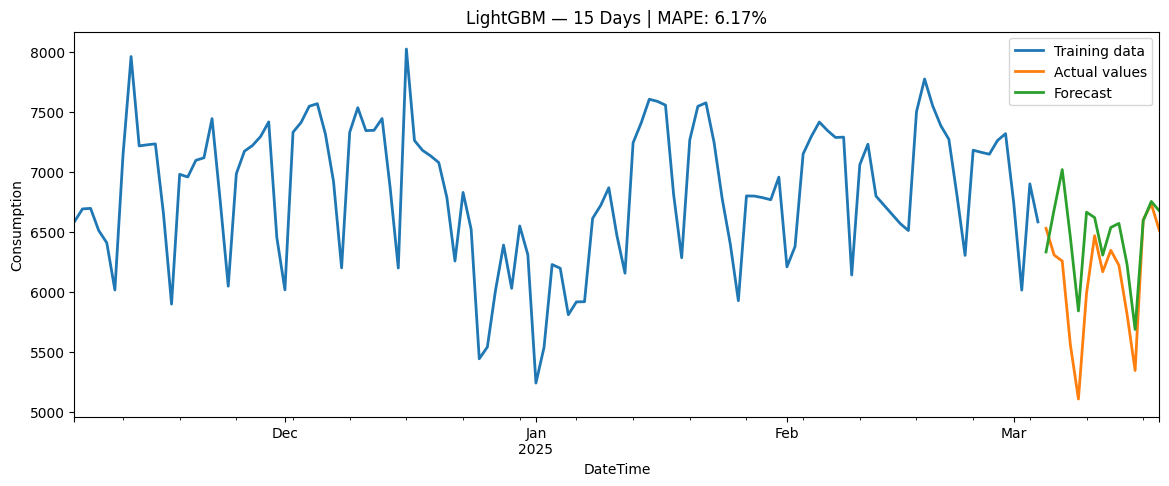

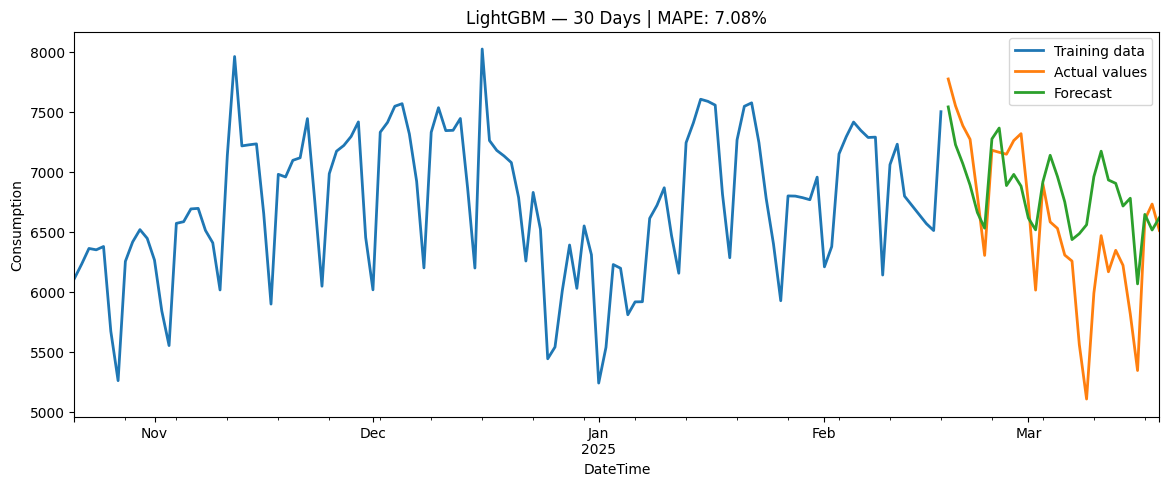

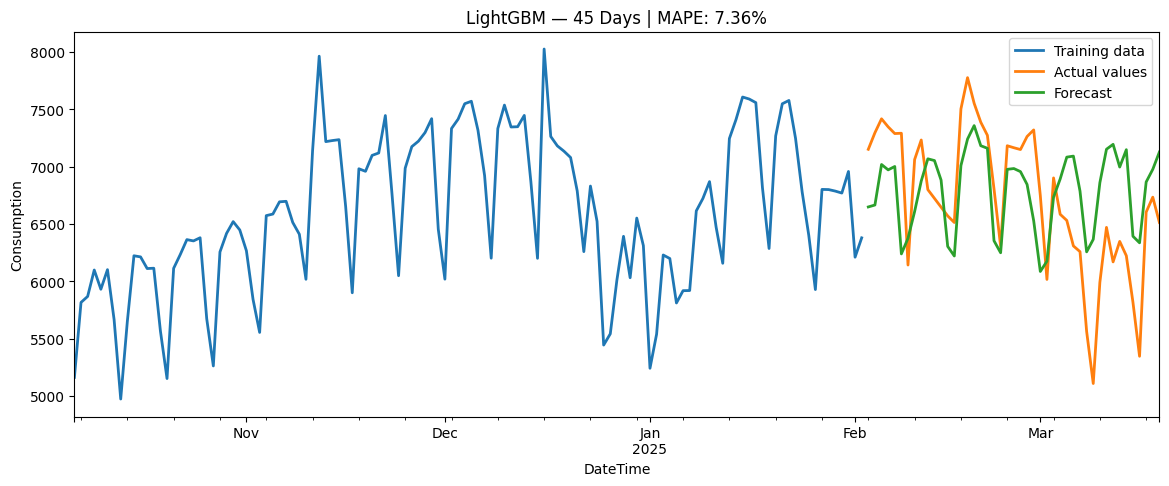

In [34]:
for horizon, (train, test) in lightgbm_splits.items():
    forecast = forecasts[f"LightGBM_{horizon}"]
    score = evaluate_forecast(test, forecast)

    plt.figure(figsize=(14, 5))

    train[-120:].plot(label="Training data")
    test.plot(label="Actual values")
    forecast.plot(label="Forecast")

    plt.title(f"LightGBM — {horizon} Days | MAPE: {score}%")
    plt.ylabel("Consumption")
    plt.legend()
    plt.show()

### Updated Results

In [35]:
results_df = pd.DataFrame(results)

results_df

,Model,Horizon,MAPE
0,Exponential Smoothing,15,4.139
1,Exponential Smoothing,30,15.205
2,Exponential Smoothing,45,9.908
3,SARIMA,15,3.592
4,SARIMA,30,8.674
5,SARIMA,45,4.304
6,Prophet,15,7.592
7,Prophet,30,5.600
8,Prophet,45,5.412
9,LightGBM,15,6.170


## 5.5 Amazon Chronos Zero-Shot

### Import Chronos Tools

In [36]:
import torch
from chronos import ChronosPipeline
from darts import TimeSeries

### Load Chronos Model

In [37]:
chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu",
    torch_dtype=torch.float32
)

`torch_dtype` is deprecated! Use `dtype` instead!


### Train Chronos Zero-Shot Forecasts

In [38]:
chronos_splits = {
    15: (train_15, test_15),
    30: (train_30, test_30),
    45: (train_45, test_45)
}

for horizon, (train, test) in chronos_splits.items():
    context = torch.tensor(train.values().flatten(), dtype=torch.float32)

    prediction = chronos_pipeline.predict(
        context,
        prediction_length=horizon,
        num_samples=20
    )

    forecast_values = prediction[0].mean(dim=0).detach().numpy()

    forecast = TimeSeries.from_times_and_values(
        test.time_index,
        forecast_values
    )

    forecasts[f"Chronos_{horizon}"] = forecast

    results.append({
        "Model": "Chronos",
        "Horizon": horizon,
        "MAPE": evaluate_forecast(test, forecast)
    })

### Chronos Forecast Visualization

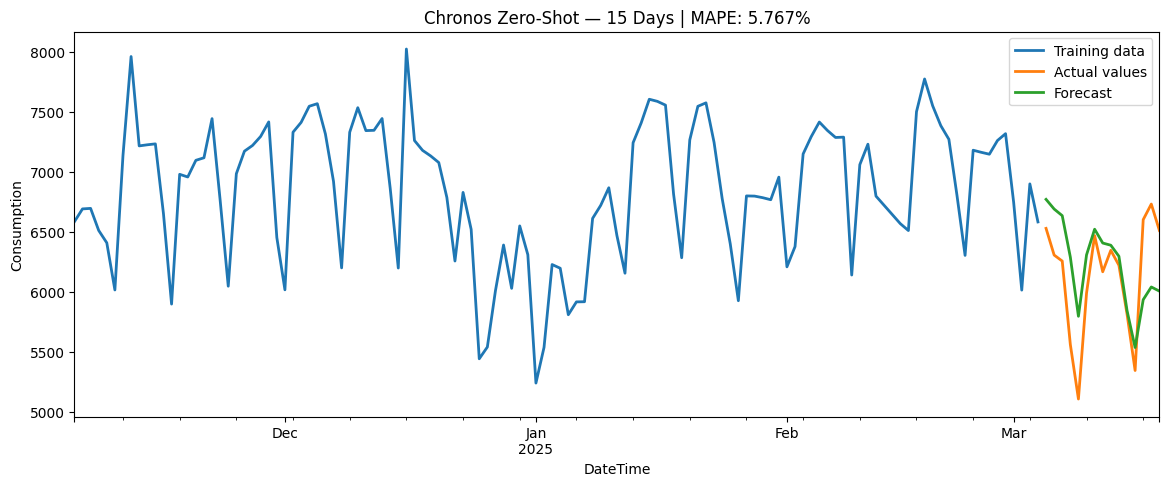

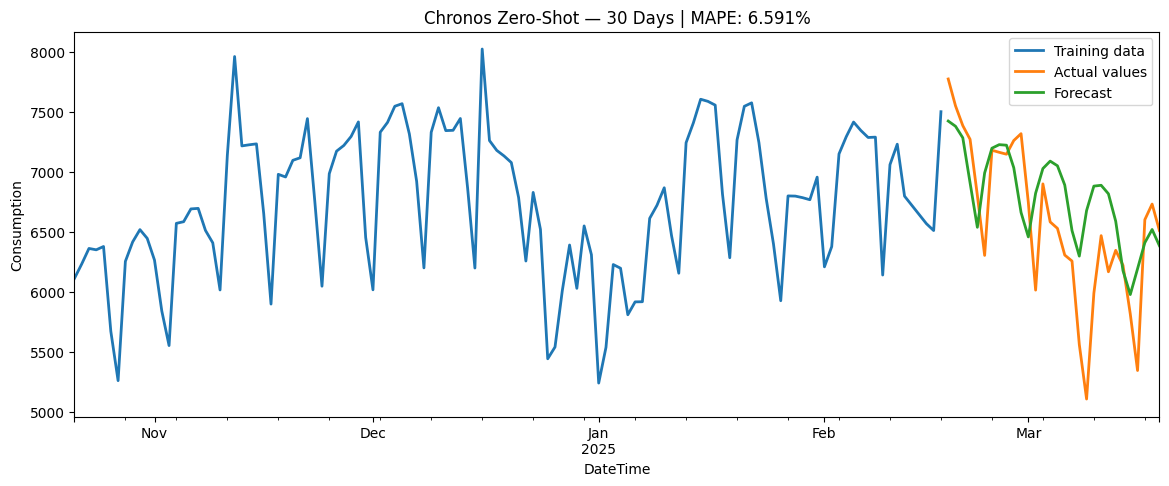

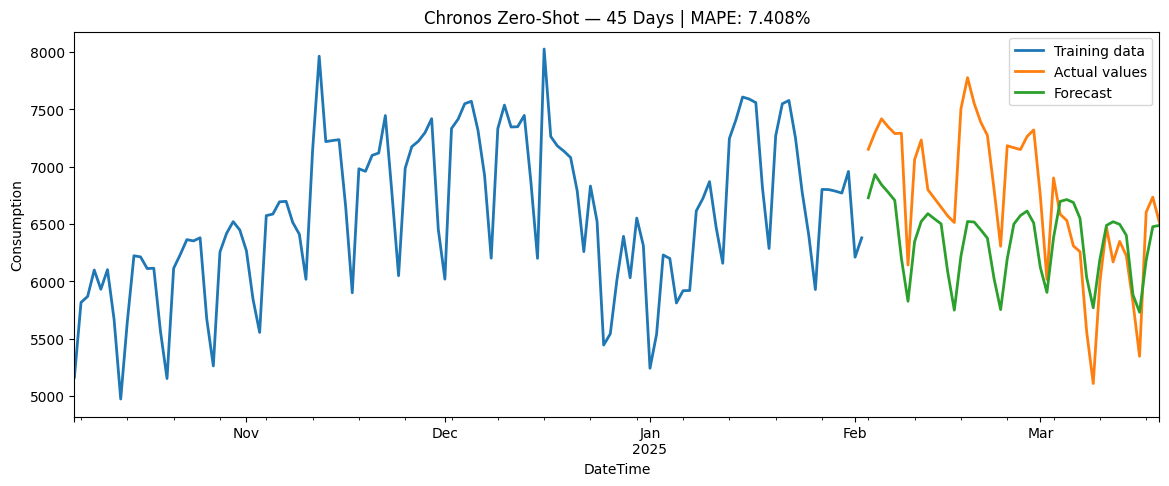

In [39]:
for horizon, (train, test) in chronos_splits.items():
    forecast = forecasts[f"Chronos_{horizon}"]
    score = evaluate_forecast(test, forecast)

    plt.figure(figsize=(14, 5))

    train[-120:].plot(label="Training data")
    test.plot(label="Actual values")
    forecast.plot(label="Forecast")

    plt.title(f"Chronos Zero-Shot — {horizon} Days | MAPE: {score}%")
    plt.ylabel("Consumption")
    plt.legend()
    plt.show()

### Updated Results with Chronos

In [40]:
results_df = pd.DataFrame(results)

results_df

,Model,Horizon,MAPE
0,Exponential Smoothing,15,4.139
1,Exponential Smoothing,30,15.205
2,Exponential Smoothing,45,9.908
3,SARIMA,15,3.592
4,SARIMA,30,8.674
5,SARIMA,45,4.304
6,Prophet,15,7.592
7,Prophet,30,5.600
8,Prophet,45,5.412
9,LightGBM,15,6.170


## 6 Model Evaluation

### Remove Duplicate Results

In [41]:
results_df = pd.DataFrame(results)

results_df = results_df.drop_duplicates(
    subset=["Model", "Horizon"],
    keep="last"
)

results_df

,Model,Horizon,MAPE
0,Exponential Smoothing,15,4.139
1,Exponential Smoothing,30,15.205
2,Exponential Smoothing,45,9.908
3,SARIMA,15,3.592
4,SARIMA,30,8.674
5,SARIMA,45,4.304
6,Prophet,15,7.592
7,Prophet,30,5.600
8,Prophet,45,5.412
9,LightGBM,15,6.170


### Final Results Table

In [42]:
results_df

,Model,Horizon,MAPE
0,Exponential Smoothing,15,4.139
1,Exponential Smoothing,30,15.205
2,Exponential Smoothing,45,9.908
3,SARIMA,15,3.592
4,SARIMA,30,8.674
5,SARIMA,45,4.304
6,Prophet,15,7.592
7,Prophet,30,5.600
8,Prophet,45,5.412
9,LightGBM,15,6.170


### MAPE Comparison Table

In [43]:
results_pivot = results_df.pivot_table(
    index="Model",
    columns="Horizon",
    values="MAPE"
)

results_pivot

Horizon,15,30,45
Model,,,
Chronos,5.767,6.591,7.408
Exponential Smoothing,4.139,15.205,9.908
LightGBM,6.170,7.080,7.360
Prophet,7.592,5.600,5.412
SARIMA,3.592,8.674,4.304


### Best Model for Each Horizon

In [44]:
best_models = results_df.loc[
    results_df.groupby("Horizon")["MAPE"].idxmin()
]

best_models

,Model,Horizon,MAPE
3,SARIMA,15,3.592
7,Prophet,30,5.600
5,SARIMA,45,4.304


### MAPE Comparison Plot

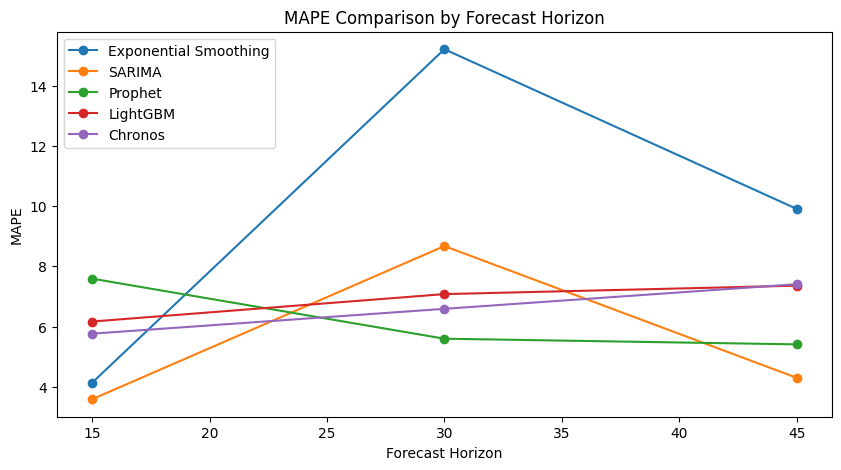

In [45]:
plt.figure(figsize=(10, 5))

for model_name in results_df["Model"].unique():
    model_data = results_df[results_df["Model"] == model_name]
    plt.plot(
        model_data["Horizon"],
        model_data["MAPE"],
        marker="o",
        label=model_name
    )

plt.title("MAPE Comparison by Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAPE")
plt.legend()
plt.show()

### Styled Results Table

In [46]:
results_pivot.style.background_gradient(cmap="Blues")

Horizon,15,30,45
Model,,,
Chronos,5.767000,6.591000,7.408000
Exponential Smoothing,4.139000,15.205000,9.908000
LightGBM,6.170000,7.080000,7.360000
Prophet,7.592000,5.600000,5.412000
SARIMA,3.592000,8.674000,4.304000


## 7 Conclusion

In this homework, the electricity consumption time series for Romania was analyzed and forecasted using the `Consumption` column. The data was resampled to daily frequency, missing values were handled using interpolation, and exploratory analysis was performed using decomposition, ACF/PACF plots, and the Augmented Dickey-Fuller test.

Several forecasting models were trained and compared for three forecast horizons: 15, 30, and 45 days. The models included Exponential Smoothing, SARIMA, Prophet, LightGBM, and Amazon Chronos as a zero-shot forecasting model. The forecasts were evaluated using the MAPE metric.

According to the final comparison, different models performed better for different forecast horizons. SARIMA showed strong results for short and longer horizons, while Chronos and Prophet were competitive for the 30-day forecast. This shows that model performance depends on the selected forecasting horizon.

Overall, the work demonstrates the full time series forecasting workflow: data preparation, exploratory analysis, model training, forecast visualization, and model comparison using a common evaluation metric.